# Load Data

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\maxan\OneDrive\Desktop\0. Personal Projects\market-intelligence-pipeline")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [3]:
import pandas as pd
import numpy as np
import duckdb

from src.config import (
    DATABASE_PATH,
    ROLLING_WINDOWS,
    LAGGED_WINDOWS,
    MA_WINDOWS,
    TICKERS,
    START_DATE,
    END_DATE
)

from src.features import (
    build_price_feature_columns
)

CALENDAR = "no_calendar"


def pull_calendar_table(table_name: str, calendar: str) -> pd.DataFrame:

    print("[START] Connecting to database...")

    con = duckdb.connect(DATABASE_PATH)

    print(f"[START] Reading {table_name}")

    df = con.sql(f"""
    
        SELECT *
        FROM {table_name}

    """).df()

    print(f"[DONE] Read {table_name}")

    con.close()

    print(f"[START] Building {CALENDAR} required columns...")

    base_cols = [
        "ticker",
        "date",
        "open",
        "high",
        "low",
        "close",
        "adj_close",
        "volume"
    ]

    feature_columns = build_price_feature_columns(
        calendars = [CALENDAR],
        rolling_windows = ROLLING_WINDOWS,
        lagged_windows = LAGGED_WINDOWS,
        ma_windows = MA_WINDOWS
    )

    expected_columns = base_cols + list(feature_columns.keys())

    calendar_df = df[expected_columns].copy()

    print(f"[DONE] Filtered to {CALENDAR}")

    calendar_df["date"] = pd.to_datetime(calendar_df["date"])

    calendar_df = calendar_df.sort_values(["ticker", "date"])

    print(f"[DONE] Prepared and sorted table")

    return calendar_df

In [5]:
df = pull_calendar_table(
    table_name = "price_features", 
    calendar = CALENDAR
    )

print(f"[STEP] Loaded price_features table selecting {CALENDAR} columns")
print(df.head(10))
print(df.columns)

[START] Connecting to database...
[START] Reading price_features
[DONE] Read price_features
[START] Building no_calendar required columns...
[DONE] Filtered to no_calendar
[DONE] Prepared and sorted table
[STEP] Loaded price_features table selecting no_calendar columns
      ticker       date        open        high         low       close  \
0        GLD 2018-01-02  124.660004  125.180000  124.389999  125.150002   
1        GLD 2018-01-03  125.050003  125.089996  124.099998  124.820000   
8585     GLD 2018-01-04  124.889999  125.849998  124.739998  125.459999   
4299     GLD 2018-01-05  124.930000  125.480003  124.830002  125.330002   
2        GLD 2018-01-08  125.199997  125.320000  124.900002  125.309998   
7160     GLD 2018-01-09  124.489998  124.860001  124.230003  124.730003   
4300     GLD 2018-01-10  125.169998  125.309998  124.720001  125.029999   
10109    GLD 2018-01-11  125.370003  125.660004  125.250000  125.440002   
10110    GLD 2018-01-12  126.010002  127.129997  125.80

In [ ]:
table_count = 0
graph_count = 0

# Target Next Day Return

In [41]:
df_1 = df.copy()

target_col = f"target_next_day_return_{CALENDAR}"

tndr_series = df_1[target_col]

tndr_summary = tndr_series.agg([
    "mean",
    "median",
    "std",
    "min",
    "max",
    "skew",
    "kurt"
])

tndr_summary.loc["p1"] = tndr_series.quantile(0.01)
tndr_summary.loc["p99"] = tndr_series.quantile(0.99)

# .T means transpose
tndr_summary_df = tndr_summary.to_frame().T
tndr_summary_df.index = ["Overall"]

print("Overall TNDR Summary Across All Assets:")
display(tndr_summary_df)



ticker_summary_rows = []

tndr_ticker_df = df_1[["ticker",target_col]]

for ticker, group in tndr_ticker_df.groupby("ticker"):
    tndr_ticker_summary = group[target_col].agg([
        "mean",
        "median",
        "std",
        "min",
        "max",
        "skew",
        "kurt"
    ])

    tndr_ticker_summary.loc["p1"] = group[target_col].quantile(0.01)
    tndr_ticker_summary.loc["p99"] = group[target_col].quantile(0.99)

    tndr_ticker_summary = tndr_ticker_summary.to_frame().T
    tndr_ticker_summary.index = [ticker]

    ticker_summary_rows.append(tndr_ticker_summary)

tndr_ticker_summary_df = pd.concat(ticker_summary_rows)

print("Ticker TNDR Summary:")
display(tndr_ticker_summary_df)



tndr_date_df = df_1[["date", target_col]]
tndr_date_df["year"] = df["date"].dt.year

tndr_summary_by_date = (
    tndr_date_df
    .groupby("year")[target_col]
    .agg(
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
        skew="skew",
        kurt="kurt",
        p1=lambda x: x.quantile(0.01),
        p99=lambda x: x.quantile(0.99)
    )
)

# Removes the blank row.
tndr_summary_by_date.index.name = None

print("Year TNDR Summary:")
display(tndr_summary_by_date)

table_list = [tndr_summary_df, tndr_ticker_summary_df, tndr_summary_by_date]


Overall TNDR Summary Across All Assets:


,mean,median,std,min,max,skew,kurt,p1,p99
Overall,0.001152,0.00057,0.024132,-0.213016,0.47091,1.720056,32.236225,-0.062637,0.078408


Ticker TNDR Summary:


,mean,median,std,min,max,skew,kurt,p1,p99
GLD,0.000564,0.000619,0.010588,-0.102742,0.063587,-0.636367,7.305299,-0.030544,0.027924
MU,0.002091,0.001012,0.033101,-0.198186,0.192916,0.175578,3.593143,-0.079828,0.097890
NKE,0.000087,0.000000,0.021387,-0.199809,0.155314,-0.268748,12.821108,-0.057467,0.055998
RPI.L,0.002499,-0.001033,0.047394,-0.139640,0.470910,3.267675,26.666113,-0.095784,0.149991
SNDK,0.014118,0.008176,0.064327,-0.213016,0.286494,0.345475,2.506943,-0.155648,0.174566
SPY,0.000614,0.000900,0.012091,-0.109424,0.105019,-0.294439,13.116533,-0.033655,0.028521
TLT,-0.000013,0.000123,0.009738,-0.066683,0.075196,0.161246,5.043367,-0.023337,0.024603


Year TNDR Summary:


,mean,median,std,min,max,skew,kurt,p1,p99
2018,-0.000017,0.000172,0.017193,-0.098708,0.113706,0.001590,8.024218,-0.057854,0.050369
2019,0.001260,0.001203,0.014912,-0.110905,0.133415,0.468563,11.081058,-0.042178,0.047834
2020,0.001189,0.001438,0.023514,-0.198186,0.151751,-0.290356,10.326229,-0.070029,0.073898
2021,0.000550,0.000440,0.015220,-0.064417,0.155314,0.878589,12.715144,-0.046496,0.044446
2022,-0.000966,-0.001154,0.020399,-0.128081,0.121790,0.043886,3.784291,-0.058151,0.054146
2023,0.000705,0.000270,0.014758,-0.118257,0.086288,0.403832,7.196704,-0.035409,0.047948
2024,0.000680,0.000906,0.020578,-0.199809,0.157480,-0.274193,17.178803,-0.060185,0.060702
2025,0.002293,0.000910,0.031859,-0.213016,0.286494,0.653459,12.552230,-0.080006,0.114199
2026,0.005784,0.000695,0.047252,-0.159538,0.470910,2.405737,18.375886,-0.107236,0.156095


In [42]:
for table in table_list:
    table = table.copy()
    table["mean_minus_median"] = (
        table["mean"] - table["median"]
    )
    display(table)



,mean,median,std,min,max,skew,kurt,p1,p99,mean_minus_median
Overall,0.001152,0.00057,0.024132,-0.213016,0.47091,1.720056,32.236225,-0.062637,0.078408,0.000583


,mean,median,std,min,max,skew,kurt,p1,p99,mean_minus_median
GLD,0.000564,0.000619,0.010588,-0.102742,0.063587,-0.636367,7.305299,-0.030544,0.027924,-0.000054
MU,0.002091,0.001012,0.033101,-0.198186,0.192916,0.175578,3.593143,-0.079828,0.097890,0.001079
NKE,0.000087,0.000000,0.021387,-0.199809,0.155314,-0.268748,12.821108,-0.057467,0.055998,0.000087
RPI.L,0.002499,-0.001033,0.047394,-0.139640,0.470910,3.267675,26.666113,-0.095784,0.149991,0.003532
SNDK,0.014118,0.008176,0.064327,-0.213016,0.286494,0.345475,2.506943,-0.155648,0.174566,0.005942
SPY,0.000614,0.000900,0.012091,-0.109424,0.105019,-0.294439,13.116533,-0.033655,0.028521,-0.000286
TLT,-0.000013,0.000123,0.009738,-0.066683,0.075196,0.161246,5.043367,-0.023337,0.024603,-0.000136


,mean,median,std,min,max,skew,kurt,p1,p99,mean_minus_median
2018,-0.000017,0.000172,0.017193,-0.098708,0.113706,0.001590,8.024218,-0.057854,0.050369,-0.000188
2019,0.001260,0.001203,0.014912,-0.110905,0.133415,0.468563,11.081058,-0.042178,0.047834,0.000057
2020,0.001189,0.001438,0.023514,-0.198186,0.151751,-0.290356,10.326229,-0.070029,0.073898,-0.000249
2021,0.000550,0.000440,0.015220,-0.064417,0.155314,0.878589,12.715144,-0.046496,0.044446,0.000110
2022,-0.000966,-0.001154,0.020399,-0.128081,0.121790,0.043886,3.784291,-0.058151,0.054146,0.000188
2023,0.000705,0.000270,0.014758,-0.118257,0.086288,0.403832,7.196704,-0.035409,0.047948,0.000435
2024,0.000680,0.000906,0.020578,-0.199809,0.157480,-0.274193,17.178803,-0.060185,0.060702,-0.000226
2025,0.002293,0.000910,0.031859,-0.213016,0.286494,0.653459,12.552230,-0.080006,0.114199,0.001383
2026,0.005784,0.000695,0.047252,-0.159538,0.470910,2.405737,18.375886,-0.107236,0.156095,0.005089


Central tendency - mean vs median:
- Overall: 
    - General positive next day returns since both are positive.
- Ticker: 
    - RPI.L stands out with positive mean but negative median indicaiting average may be driven by a few large winners. 
    - TLT also stands out with negative mean but positive median indicating mostly positive returns bu occasianl large losses. 
    - Some assets show more positive mean compared to median indicating returns driven by few large returns.
- Year: 
    - 2022 indicates mostly negative returns while 2025 shows mostly postiive returns but occasional large spikes - possibly in one or a few assets.

In [45]:
for table in table_list:
    table = table.copy()
    table["mean_to_std"] = (
        table["mean"] / table["std"]
    )
    display(table)

,mean,median,std,min,max,skew,kurt,p1,p99,mean_to_std
Overall,0.001152,0.00057,0.024132,-0.213016,0.47091,1.720056,32.236225,-0.062637,0.078408,0.047747


,mean,median,std,min,max,skew,kurt,p1,p99,mean_to_std
GLD,0.000564,0.000619,0.010588,-0.102742,0.063587,-0.636367,7.305299,-0.030544,0.027924,0.053311
MU,0.002091,0.001012,0.033101,-0.198186,0.192916,0.175578,3.593143,-0.079828,0.097890,0.063165
NKE,0.000087,0.000000,0.021387,-0.199809,0.155314,-0.268748,12.821108,-0.057467,0.055998,0.004045
RPI.L,0.002499,-0.001033,0.047394,-0.139640,0.470910,3.267675,26.666113,-0.095784,0.149991,0.052722
SNDK,0.014118,0.008176,0.064327,-0.213016,0.286494,0.345475,2.506943,-0.155648,0.174566,0.219476
SPY,0.000614,0.000900,0.012091,-0.109424,0.105019,-0.294439,13.116533,-0.033655,0.028521,0.050755
TLT,-0.000013,0.000123,0.009738,-0.066683,0.075196,0.161246,5.043367,-0.023337,0.024603,-0.001294


,mean,median,std,min,max,skew,kurt,p1,p99,mean_to_std
2018,-0.000017,0.000172,0.017193,-0.098708,0.113706,0.001590,8.024218,-0.057854,0.050369,-0.000968
2019,0.001260,0.001203,0.014912,-0.110905,0.133415,0.468563,11.081058,-0.042178,0.047834,0.084481
2020,0.001189,0.001438,0.023514,-0.198186,0.151751,-0.290356,10.326229,-0.070029,0.073898,0.050553
2021,0.000550,0.000440,0.015220,-0.064417,0.155314,0.878589,12.715144,-0.046496,0.044446,0.036136
2022,-0.000966,-0.001154,0.020399,-0.128081,0.121790,0.043886,3.784291,-0.058151,0.054146,-0.047346
2023,0.000705,0.000270,0.014758,-0.118257,0.086288,0.403832,7.196704,-0.035409,0.047948,0.047761
2024,0.000680,0.000906,0.020578,-0.199809,0.157480,-0.274193,17.178803,-0.060185,0.060702,0.033059
2025,0.002293,0.000910,0.031859,-0.213016,0.286494,0.653459,12.552230,-0.080006,0.114199,0.071978
2026,0.005784,0.000695,0.047252,-0.159538,0.470910,2.405737,18.375886,-0.107236,0.156095,0.122402


Return to risk - mean vs volatility:
- Overall:
    - Across this period we have seen poor returns given the level of risk with a much higher volatility compared to returns.
- Ticker:
    - TLT shows negative returns wiht respect to its risk although low.
    - SNDK and RPI.L have shown very high volatility. MU shows a better balance.
- Year:
    - 2026 was a good year with high returns although high risk.
    - 2019 was the only year to show relatively good balance between risk and return.

In [55]:
from IPython.display import display, HTML

for table in table_list:
    table = table.copy()
    p1_ranked = table.sort_values("p1", ascending=False)
    min_ranked = table.sort_values("min", ascending=False)

    html = f"""
    <div style="display: flex; gap: 30px; align-items: flex-start;">
        <div>
            <h3>Ranked by p1</h3>
            {p1_ranked[["p1"]].to_html()}
        </div>
        <div>
            <h3>Ranked by min</h3>
            {min_ranked[["min"]].to_html()}
        </div>
    </div>
    """

    display(HTML(html))

,p1
Overall,-0.062637
,min
Overall,-0.213016


,p1
TLT,-0.023337
GLD,-0.030544
SPY,-0.033655
NKE,-0.057467
MU,-0.079828
RPI.L,-0.095784
SNDK,-0.155648
,min
TLT,-0.066683
GLD,-0.102742


,p1
2023,-0.035409
2019,-0.042178
2021,-0.046496
2018,-0.057854
2022,-0.058151
2024,-0.060185
2020,-0.070029
2025,-0.080006
2026,-0.107236
,min


Downside risk - min and p1:
- Overall:
    - Both are negative but more negative min indicates some very negative events occuring.
- Ticker:
    - SNDK has extremely negative p1 indicating repeated downside tail risk, much worse compared to other tickers.
- Year:
    - 2026 seems to be the worst for downside tail risk compared to other years including COVID crash.


In [54]:
from IPython.display import display, HTML

for table in table_list:
    table = table.copy()
    p99_ranked = table.sort_values("p99", ascending=False)
    max_ranked = table.sort_values("max", ascending=False)

    html = f"""
    <div style="display: flex; gap: 30px; align-items: flex-start;">
        <div>
            <h3>Ranked by p99</h3>
            {p99_ranked[["p99"]].to_html()}
        </div>
        <div>
            <h3>Ranked by max</h3>
            {max_ranked[["max"]].to_html()}
        </div>
    </div>
    """

    display(HTML(html))

,p99
Overall,0.078408
,max
Overall,0.47091


,p99
SNDK,0.174566
RPI.L,0.149991
MU,0.097890
NKE,0.055998
SPY,0.028521
GLD,0.027924
TLT,0.024603
,max
RPI.L,0.470910
SNDK,0.286494


,p99
2026,0.156095
2025,0.114199
2020,0.073898
2024,0.060702
2022,0.054146
2018,0.050369
2023,0.047948
2019,0.047834
2021,0.044446
,max


Upside benefit - max and p99:
- Overall:
    - Some very large outlier type gains as max is much larger than p99.
- Ticker:
    - RPI.L demosntrates one off extreme positive event, showing highest one day return out of all tickers.
    - MU shows strong upside tail and most attractive symmetry.
- Year:
    - 2026 and 2025 show best upside and highest return.
    - 2020 shows high upside but not highest return.

In [57]:
from IPython.display import display, HTML

html_parts = []

for i, table in enumerate(table_list, start=1):
    table = table.copy()
    table = table.sort_values("skew")

    skew_table = table[["skew"]]

    html_parts.append(f"""
    <div>
        <h3>Table {i} — ranked by skew</h3>
        {skew_table.to_html()}
    </div>
    """)

html = f"""
<div style="display: flex; gap: 30px; align-items: flex-start;">
    {''.join(html_parts)}
</div>
"""

display(HTML(html))

,skew
Overall,1.720056
,skew
GLD,-0.636367
SPY,-0.294439
NKE,-0.268748
TLT,0.161246
MU,0.175578
SNDK,0.345475
RPI.L,3.267675
,skew


Skew:
- Overall:
    - positive skew indicating more upside tail or occasional large gains.
- Ticker:
    - AI assets very positive indicating very large upside tail or the more likley large occasional gains
- Year:
    - 2026 and 2021 show most upside gains likley from AI and COVID bounce back.

In [58]:
from IPython.display import display, HTML

html_parts = []

for i, table in enumerate(table_list, start=1):
    table = table.copy()
    table = table.sort_values("kurt")

    skew_table = table[["kurt"]]

    html_parts.append(f"""
    <div>
        <h3>Table {i} — ranked by kurt</h3>
        {skew_table.to_html()}
    </div>
    """)

html = f"""
<div style="display: flex; gap: 30px; align-items: flex-start;">
    {''.join(html_parts)}
</div>
"""

display(HTML(html))

,kurt
Overall,32.236225
,kurt
SNDK,2.506943
MU,3.593143
TLT,5.043367
GLD,7.305299
NKE,12.821108
SPY,13.116533
RPI.L,26.666113
,kurt


Kurtosis:
- Overall:
    - demonstrates very large number of extreme outcomes has occured comapred to normal distribution.
- Ticker:
    - RPI.L shows the most extreme returns whiel SNDK suprisingly has the lowest.
- Year:
    - 2026 shows the most extreme returns while 2024 comes second.

# Target Direction

In [72]:
df_2 = df.copy()

date = "date"
ticker = "ticker"
target_direction = f"target_direction_{CALENDAR}"
target_return = f"target_next_day_return_{CALENDAR}"

TND_df = df_2[[date, ticker, target_return, target_direction]]

overall = pd.DataFrame({
    "n_distinct": [TND_df[target_direction].nunique()],
    "n_missing": [TND_df[target_direction].isna().sum()],
    "n_zeros": [(TND_df[target_return] == 0).sum()],
    "pct_zeros": [(TND_df[target_return] == 0).mean() * 100],
})

display(overall)

zero_dates = TND_df.loc[TND_df[target_return] == 0, [date, ticker, target_return,target_direction]]

display(zero_dates.sort_values("date"))

,n_distinct,n_missing,n_zeros,pct_zeros
0,2,7,42,0.364141


,date,ticker,target_next_day_return_no_calendar,target_direction_no_calendar
4,2018-03-09,GLD,0.0,0
4061,2018-03-14,TLT,0.0,0
3143,2018-04-10,MU,0.0,0
2362,2018-05-07,SPY,0.0,0
10424,2018-06-08,MU,0.0,0
1190,2018-09-14,TLT,0.0,0
5207,2018-10-05,SPY,0.0,0
562,2018-11-13,NKE,0.0,0
30,2018-11-19,GLD,0.0,0
3165,2019-02-08,MU,0.0,0


Only two classes which is expected. 7 missing target returns are all form the first row of the dataset where there is no previous return to shift forward. Weridly there are  return days listed above - none of whcih are on the same day. Zero return days are classified as 0 or down.

# Class Balance for Target Direction

In [79]:
df_3 = df.copy()

ticker = "ticker"
target_direction = f"target_direction_{CALENDAR}"
target_return = f"target_next_day_return_{CALENDAR}"

TND_df = df_3[[date, ticker, target_return, target_direction]]

overall = pd.DataFrame({
    "up_days": [(TND_df[target_direction] == 1).sum()],
    "down_days": [(TND_df[target_direction] == 0).sum()],
    "total_observations": TND_df[target_direction].count()
})

display(overall)

ticker_summary_rows = []

for ticker, group in TND_df.groupby("ticker"):
    ticker_summary_row = pd.DataFrame({
        "up_days": [(group[target_direction] == 1).sum()],
        "down_days": [(group[target_direction] == 0).sum()],
        "total_observations": group[target_direction].count()
    })

    ticker_summary_row.index = [ticker]

    ticker_summary_rows.append(ticker_summary_row)

ticker_summary_df = pd.concat(ticker_summary_rows)

display(ticker_summary_df)

,up_days,down_days,total_observations
0,6023,5504,11527


,up_days,down_days,total_observations
GLD,1148,985,2133
MU,1112,1021,2133
NKE,1065,1068,2133
RPI.L,246,272,518
SNDK,196,148,344
SPY,1181,952,2133
TLT,1075,1058,2133


# Percent of Up vs Down Days

In [83]:
df_4 = df.copy()

ticker = "ticker"
target_direction = f"target_direction_{CALENDAR}"
target_return = f"target_next_day_return_{CALENDAR}"

TND_df = df_4[[date, ticker, target_return, target_direction]]

overall = pd.DataFrame({
    "up_days %": [(TND_df[target_direction] == 1).mean()*100],
    "down_days %": [(TND_df[target_direction] == 0).mean()*100],
    "total_observations": TND_df[target_direction].count()
})

display(overall)

ticker_summary_rows = []

for ticker, group in TND_df.groupby("ticker"):
    ticker_summary_row = pd.DataFrame({
        "up_days %": [(group[target_direction] == 1).mean()*100],
        "down_days %": [(group[target_direction] == 0).mean()*100],
        "total_observations": group[target_direction].count()
    })

    ticker_summary_row.index = [ticker]

    ticker_summary_rows.append(ticker_summary_row)

ticker_summary_df = pd.concat(ticker_summary_rows)

display(ticker_summary_df.sort_values("up_days %"))

,up_days %,down_days %,total_observations
0,52.251236,47.748764,11527


,up_days %,down_days %,total_observations
RPI.L,47.490347,52.509653,518
NKE,49.929677,50.070323,2133
TLT,50.398500,49.601500,2133
MU,52.133146,47.866854,2133
GLD,53.820910,46.179090,2133
SPY,55.368026,44.631974,2133
SNDK,56.976744,43.023256,344


# Target Behaviour By Ticker

In [84]:
df_analysis = df.copy()

ticker_col = "ticker"
date_col = "date"

target_return = f"target_next_day_return_{CALENDAR}"
target_direction = f"target_direction_{CALENDAR}"

df_analysis[date_col] = pd.to_datetime(df_analysis[date_col])
df_analysis["year"] = df_analysis[date_col].dt.year

In [101]:
asset_summary = (
    df_analysis
    .groupby(ticker_col)[target_return]
    .agg(
        n_obs="count",
        mean_return="mean",
        median_return="median",
        volatility="std",
        min_return="min",
        max_return="max",
        p1=lambda x: x.quantile(0.01),
        p99=lambda x: x.quantile(0.99),
        skew="skew",
        kurtosis="kurt",
        up_pct=lambda x: (x > 0).mean() * 100,
        down_pct=lambda x: (x < 0).mean() * 100,
        zero_pct=lambda x: (x == 0).mean() * 100,
        missing_count=lambda x: x.isna().sum(),
        missing_pct=lambda x: x.isna().mean() * 100,
    ).reset_index()
)

asset_summary["tail_range"] = asset_summary["p99"] - asset_summary["p1"]
asset_summary["mean_to_vol"] = asset_summary["mean_return"] / asset_summary["volatility"]

display(asset_summary)

,ticker,n_obs,mean_return,median_return,volatility,min_return,max_return,p1,p99,skew,kurtosis,up_pct,down_pct,zero_pct,missing_count,missing_pct,tail_range,mean_to_vol
0,GLD,2133,0.000564,0.000619,0.010588,-0.102742,0.063587,-0.030544,0.027924,-0.636367,7.305299,53.795689,45.876289,0.281162,1,0.046860,0.058468,0.053311
1,MU,2133,0.002091,0.001012,0.033101,-0.198186,0.192916,-0.079828,0.097890,0.175578,3.593143,52.108716,47.610122,0.234302,1,0.046860,0.177718,0.063165
2,NKE,2133,0.000087,0.000000,0.021387,-0.199809,0.155314,-0.057467,0.055998,-0.268748,12.821108,49.906279,49.578257,0.468604,1,0.046860,0.113464,0.004045
3,RPI.L,518,0.002499,-0.001033,0.047394,-0.139640,0.470910,-0.095784,0.149991,3.267675,26.666113,47.398844,50.481696,1.926782,1,0.192678,0.245776,0.052722
4,SNDK,344,0.014118,0.008176,0.064327,-0.213016,0.286494,-0.155648,0.174566,0.345475,2.506943,56.811594,42.898551,0.000000,1,0.289855,0.330214,0.219476
5,SPY,2133,0.000614,0.000900,0.012091,-0.109424,0.105019,-0.033655,0.028521,-0.294439,13.116533,55.342081,44.423618,0.187441,1,0.046860,0.062176,0.050755
6,TLT,2133,-0.000013,0.000123,0.009738,-0.066683,0.075196,-0.023337,0.024603,0.161246,5.043367,50.374883,49.250234,0.328022,1,0.046860,0.047939,-0.001294


In [105]:
sort_columns = ["mean_return", "volatility", "up_pct", "p1", "p99", "kurtosis"]

tables = {}

for col in sort_columns:
    tables[col] = asset_summary[["ticker", col]].sort_values(col, ascending = False)

html_parts = []

for name, table in tables.items():

    html_parts.append(f"""
    <div>
        <h3> {name} </h3>
        {table.to_html(index=False)}
    </div>
    """)

html = f"""
<div style="display: flex; gap: 30px; align-items: flex-start;">
    {''.join(html_parts)}
</div>
"""

display(HTML(html))

ticker,mean_return
SNDK,0.014118
RPI.L,0.002499
MU,0.002091
SPY,0.000614
GLD,0.000564
NKE,0.000087
TLT,-0.000013
ticker,volatility
SNDK,0.064327
RPI.L,0.047394


SDNK has highest mean_return but is also the noisiest. SNDK is generally more up, surprisingly more than the SPY although has larger moves in either the up and down direction. RPI.L has the fatest tails showing abnormally large moves compared to day to day returns while surprisingly SNDK has the lowst kurtosis indicating that it has the greatest movements in terms of size, but actually those large movements are more regular for SNDK.

In [114]:
asset_year_summary = (
    df_analysis
    .groupby([ticker_col, "year"])[target_return]
    .agg(
        n_obs="count",
        mean_return="mean",
        median_return="median",
        volatility="std",
        min_return="min",
        max_return="max",
        p1=lambda x: x.quantile(0.01),
        p99=lambda x: x.quantile(0.99),
        skew="skew",
        kurtosis="kurt",
        up_pct=lambda x: (x > 0).mean() * 100,
        down_pct=lambda x: (x < 0).mean() * 100,
        zero_pct=lambda x: (x == 0).mean() * 100,
    ).reset_index()
)

asset_year_summary["tail_range"] = (
    asset_year_summary["p99"] - asset_year_summary["p1"]
)

display(asset_year_summary)

,ticker,year,n_obs,mean_return,median_return,volatility,min_return,max_return,p1,p99,skew,kurtosis,up_pct,down_pct,zero_pct,tail_range
0,GLD,2018,251,-0.000105,0.000000e+00,0.006095,-0.016627,0.025691,-0.015615,0.017255,0.321377,1.635473,49.800797,49.402390,0.796813,0.032870
1,GLD,2019,252,0.000706,9.075737e-04,0.007356,-0.024001,0.025178,-0.017766,0.020457,0.011781,1.107337,54.761905,44.047619,1.190476,0.038223
2,GLD,2020,253,0.001011,2.160609e-03,0.012334,-0.053694,0.048530,-0.038123,0.029498,-0.524480,3.457282,58.893281,41.106719,0.000000,0.067621
3,GLD,2021,252,-0.000280,-5.480103e-07,0.008555,-0.034210,0.021271,-0.024579,0.017226,-0.686461,1.563130,50.000000,50.000000,0.000000,0.041805
4,GLD,2022,251,0.000110,4.315313e-04,0.009591,-0.029711,0.030696,-0.019958,0.025834,0.162655,0.673831,50.996016,49.003984,0.000000,0.045792
5,GLD,2023,250,0.000471,1.672423e-04,0.008424,-0.024958,0.032148,-0.019832,0.022759,0.352113,1.292895,50.800000,48.800000,0.400000,0.042592
6,GLD,2024,252,0.001046,1.649015e-03,0.009489,-0.035683,0.022388,-0.027033,0.019223,-0.558855,1.010341,56.746032,43.253968,0.000000,0.046256
7,GLD,2025,250,0.002017,2.012570e-03,0.012487,-0.064269,0.036991,-0.028019,0.031754,-0.614647,3.447207,60.000000,40.000000,0.000000,0.059773
8,GLD,2026,122,-0.000372,3.288476e-04,0.021565,-0.102742,0.063587,-0.043949,0.038589,-0.794181,3.599065,50.406504,48.780488,0.000000,0.082538
9,MU,2018,251,-0.000668,2.121766e-04,0.030889,-0.098708,0.113706,-0.079765,0.064213,-0.151014,0.961621,50.597610,48.605578,0.796813,0.143978


In [122]:
sort_columns = ["mean_return", "volatility", "up_pct", "p1", "p99", "kurtosis"]

for col in sort_columns:

    by_year = asset_year_summary.pivot(
        index="ticker",
        columns="year",
        values=f"{col}"
    )

    by_year.columns.name = None
    by_year.index.name = None

    print(f"Unstacked {col} by year")
    display(by_year)

Unstacked mean_return by year


,2018,2019,2020,2021,2022,2023,2024,2025,2026
GLD,-0.000105,0.000706,0.001011,-0.000280,0.000110,0.000471,0.001046,0.002017,-0.000372
MU,-0.000668,0.002468,0.001809,0.001344,-0.002083,0.002254,0.000778,0.005956,0.012160
NKE,0.000827,0.001406,0.001625,0.000822,-0.000905,-0.000235,-0.001180,-0.000167,-0.003035
RPI.L,NaN,NaN,NaN,NaN,NaN,NaN,0.004365,-0.002686,0.011062
SNDK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011051,0.019699
SPY,-0.000153,0.001143,0.000797,0.001113,-0.000722,0.000959,0.000926,0.000744,0.000815
TLT,0.000016,0.000576,0.000702,-0.000248,-0.001228,0.000077,-0.000259,0.000178,0.000155


Unstacked volatility by year


,2018,2019,2020,2021,2022,2023,2024,2025,2026
GLD,0.006095,0.007356,0.012334,0.008555,0.009591,0.008424,0.009489,0.012487,0.021565
MU,0.030889,0.027738,0.036188,0.025106,0.029774,0.022918,0.032523,0.039883,0.055976
NKE,0.018483,0.013049,0.026142,0.017633,0.026640,0.017062,0.020187,0.026440,0.023584
RPI.L,NaN,NaN,NaN,NaN,NaN,NaN,0.034032,0.030316,0.078676
SNDK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.061202,0.069571
SPY,0.010723,0.007898,0.021052,0.008135,0.015268,0.008241,0.007910,0.012274,0.008989
TLT,0.005809,0.007542,0.013567,0.008886,0.012786,0.011554,0.008936,0.007518,0.006042


Unstacked up_pct by year


...

,2018,2019,2020,2021,2022,2023,2024,2025,2026
GLD,-0.015615,-0.017766,-0.038123,-0.024579,-0.019958,-0.019832,-0.027033,-0.028019,-0.043949
MU,-0.079765,-0.053918,-0.096273,-0.058463,-0.073302,-0.043400,-0.077592,-0.112950,-0.124832
NKE,-0.044972,-0.034062,-0.072440,-0.038652,-0.059102,-0.037825,-0.050998,-0.069029,-0.047179
RPI.L,NaN,NaN,NaN,NaN,NaN,NaN,-0.089099,-0.070159,-0.118452
SNDK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.187548,-0.131665
SPY,-0.032033,-0.025403,-0.067463,-0.021764,-0.037462,-0.016793,-0.021600,-0.035591,-0.019832
TLT,-0.012903,-0.017935,-0.043739,-0.020868,-0.026865,-0.025152,-0.021938,-0.018193,-0.014472


Unstacked p99 by year


,2018,2019,2020,2021,2022,2023,2024,2025,2026
GLD,0.017255,0.020457,0.029498,0.017226,0.025834,0.022759,0.019223,0.031754,0.038589
MU,0.064213,0.066664,0.103572,0.056835,0.072578,0.073991,0.067904,0.103326,0.156892
NKE,0.060013,0.028453,0.080104,0.033074,0.062981,0.042570,0.042028,0.068852,0.044704
RPI.L,NaN,NaN,NaN,NaN,NaN,NaN,0.098664,0.064242,0.342933
SNDK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.167731,0.208387
SPY,0.022446,0.017688,0.062602,0.018071,0.031244,0.019285,0.018882,0.023583,0.024150
TLT,0.012685,0.020345,0.046410,0.020336,0.030529,0.024850,0.017953,0.016757,0.013306


Unstacked kurtosis by year


,2018,2019,2020,2021,2022,2023,2024,2025,2026
GLD,1.635473,1.107337,3.457282,1.563130,0.673831,1.292895,1.010341,3.447207,3.599065
MU,0.961621,2.529902,4.678982,1.157804,0.218380,1.389513,4.377878,3.019489,0.713843
NKE,6.888963,3.130923,7.752011,23.471660,3.248431,9.720742,37.703871,9.258031,13.336321
RPI.L,NaN,NaN,NaN,NaN,NaN,NaN,3.660215,2.624870,12.435457
SNDK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.653317,1.131267
SPY,3.342994,3.189261,7.290779,0.725527,0.365476,-0.161867,1.816487,23.587113,0.885137
TLT,0.460300,0.430883,9.401260,0.500708,-0.112002,-0.186347,0.370185,1.068302,0.320240


In [123]:
coverage_summary = (
    df_analysis
    .groupby(ticker_col)
    .agg(
        start_date=(date_col, "min"),
        end_date=(date_col, "max"),
        n_rows=(target_return, "size"),
        n_non_missing=(target_return, "count"),
        n_missing=(target_return, lambda x: x.isna().sum()),
        missing_pct=(target_return, lambda x: x.isna().mean() * 100),
    )
)

display(coverage_summary)

,start_date,end_date,n_rows,n_non_missing,n_missing,missing_pct
ticker,,,,,,
GLD,2018-01-02,2026-06-30,2134,2133,1,0.046860
MU,2018-01-02,2026-06-30,2134,2133,1,0.046860
NKE,2018-01-02,2026-06-30,2134,2133,1,0.046860
RPI.L,2024-06-11,2026-06-30,519,518,1,0.192678
SNDK,2025-02-13,2026-06-30,345,344,1,0.289855
SPY,2018-01-02,2026-06-30,2134,2133,1,0.046860
TLT,2018-01-02,2026-06-30,2134,2133,1,0.046860


In [124]:
global_big_move_threshold = df_analysis[target_return].abs().quantile(0.99)

big_move_summary = (
    df_analysis
    .assign(big_move=lambda x: x[target_return].abs() >= global_big_move_threshold)
    .groupby(ticker_col)["big_move"]
    .agg(
        big_move_count="sum",
        big_move_pct=lambda x: x.mean() * 100,
    )
)

display(big_move_summary.sort_values("big_move_count", ascending=False))

,big_move_count,big_move_pct
ticker,,
SNDK,45,13.043478
MU,36,1.686973
RPI.L,18,3.468208
NKE,14,0.656045
SPY,2,0.093721
GLD,1,0.046860
TLT,0,0.000000


Most large moves came from AI related stocks.

# Target Noise

In [127]:
df_5 = df.copy()

ticker_col = "ticker"
date_col = "date"

target_return = f"target_next_day_return_{CALENDAR}"
target_direction = f"target_direction_{CALENDAR}"

In [130]:
import matplotlib.pyplot as plt

bins = [
    -np.inf,
    -0.02,
    -0.01,
    -0.005,
    0,
    0.005,
    0.01,
    0.02,
    np.inf
]

labels = [
    "< -2%",
    "-2% to -1%",
    "-1% to -0.5%",
    "-0.5% to 0%",
    "0% to +0.5%",
    "+0.5% to +1%",
    "+1% to +2%",
    "> +2%"
]

df_5["return_band"] = pd.cut(
    df_5[target_return],
    bins=bins,
    labels=labels,
    right=False
)

band_distribution = (
    df_5["return_band"]
    .value_counts(normalize=True)
    .reindex(labels)
    .mul(100)
    .round(2)
)

display(band_distribution)

return_band
< -2%            9.45
-2% to -1%      10.27
-1% to -0.5%    11.31
-0.5% to 0%     16.35
0% to +0.5%     18.02
+0.5% to +1%    12.55
+1% to +2%      11.63
> +2%           10.41
Name: proportion, dtype: float64

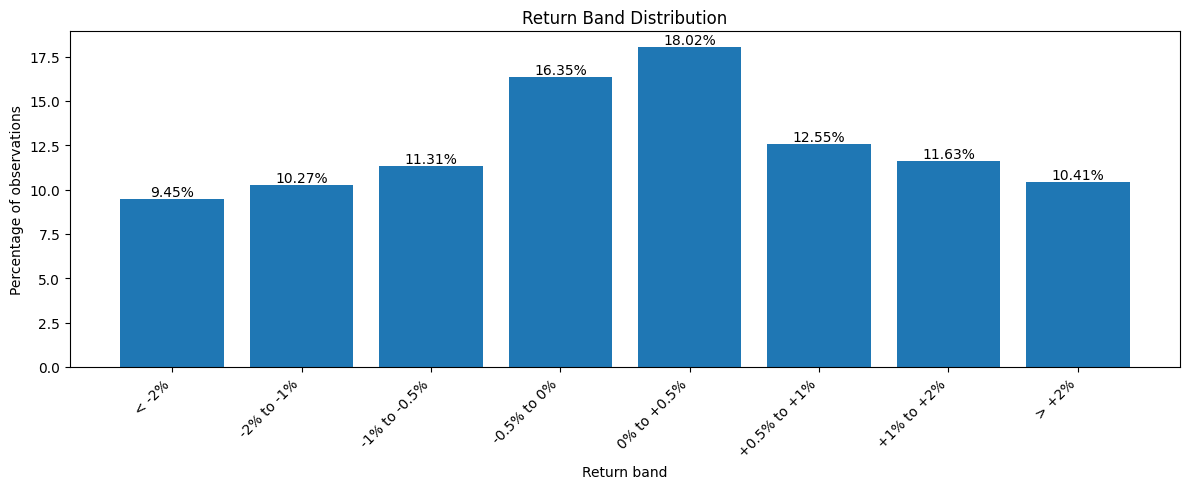

In [131]:
plt.figure(figsize=(12, 5))

bars = plt.bar(
    band_distribution.index.astype(str),
    band_distribution.values
)

plt.title("Return Band Distribution")
plt.xlabel("Return band")
plt.ylabel("Percentage of observations")
plt.xticks(rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [133]:
share_close_to_zero = (
    df[target_return]
    .between(-0.005, 0.005)
    .mean()
)

print(f"Share between -0.5% and +0.5%: {share_close_to_zero:.2%}")

Share between -0.5% and +0.5%: 34.35%


In [134]:
thresholds = [0.001, 0.0025, 0.005, 0.01, 0.02]

for threshold in thresholds:
    share = df[target_return].between(-threshold, threshold).mean()
    print(f"Share between {-threshold:.2%} and {threshold:.2%}: {share:.2%}")

Share between -0.10% and 0.10%: 7.66%
Share between -0.25% and 0.25%: 18.47%
Share between -0.50% and 0.50%: 34.35%
Share between -1.00% and 1.00%: 58.20%
Share between -2.00% and 2.00%: 80.09%


In [135]:
mean_return = df[target_return].mean()
volatility = df[target_return].std()

signal_to_noise = mean_return / volatility

print(f"Mean next-day return: {mean_return:.4%}")
print(f"Volatility of next-day return: {volatility:.4%}")
print(f"Signal-to-noise ratio: {signal_to_noise:.4f}")

Mean next-day return: 0.1152%
Volatility of next-day return: 2.4132%
Signal-to-noise ratio: 0.0477


In [136]:
annualized_mean = mean_return * 252
annualized_volatility = volatility * np.sqrt(252)
annualized_snr = annualized_mean / annualized_volatility

print(f"Annualized mean: {annualized_mean:.2%}")
print(f"Annualized volatility: {annualized_volatility:.2%}")
print(f"Annualized signal-to-noise ratio: {annualized_snr:.4f}")

Annualized mean: 29.04%
Annualized volatility: 38.31%
Annualized signal-to-noise ratio: 0.7580


In [138]:
df["year"] = df["date"].dt.year

yearly_stats = (
    df.groupby("year")
    .agg(
        mean_return=(target_return, "mean"),
        volatility=(target_return, "std"),
        pct_up=(target_return, lambda x: (x > 0).mean()),
        pct_down=(target_return, lambda x: (x < 0).mean()),
        pct_flat=(target_return, lambda x: (x == 0).mean()),
        observations=(target_return, "count")
    )
)

yearly_stats["signal_to_noise"] = (
    yearly_stats["mean_return"] / yearly_stats["volatility"]
)

yearly_stats

,mean_return,volatility,pct_up,pct_down,pct_flat,observations,signal_to_noise
year,,,,,,,
2018,-0.000017,0.017193,0.509960,0.482869,0.007171,1255,-0.000968
2019,0.001260,0.014912,0.557937,0.435714,0.006349,1260,0.084481
2020,0.001189,0.023514,0.543874,0.453755,0.002372,1265,0.050553
2021,0.000550,0.015220,0.522222,0.476984,0.000794,1260,0.036136
2022,-0.000966,0.020399,0.472510,0.526693,0.000797,1255,-0.047346
2023,0.000705,0.014758,0.506400,0.489600,0.004000,1250,0.047761
2024,0.000680,0.020578,0.535282,0.458304,0.006415,1403,0.033059
2025,0.002293,0.031859,0.529275,0.467826,0.002899,1725,0.071978
2026,0.005784,0.047252,0.515679,0.475029,0.001161,854,0.122402


In [139]:
display_stats = yearly_stats.copy()

for col in ["mean_return", "volatility", "pct_up", "pct_down", "pct_flat"]:
    display_stats[col] = display_stats[col].map(lambda x: f"{x:.2%}")

display_stats["signal_to_noise"] = display_stats["signal_to_noise"].map(lambda x: f"{x:.4f}")

display_stats

,mean_return,volatility,pct_up,pct_down,pct_flat,observations,signal_to_noise
year,,,,,,,
2018,-0.00%,1.72%,51.00%,48.29%,0.72%,1255,-0.0010
2019,0.13%,1.49%,55.79%,43.57%,0.63%,1260,0.0845
2020,0.12%,2.35%,54.39%,45.38%,0.24%,1265,0.0506
2021,0.05%,1.52%,52.22%,47.70%,0.08%,1260,0.0361
2022,-0.10%,2.04%,47.25%,52.67%,0.08%,1255,-0.0473
2023,0.07%,1.48%,50.64%,48.96%,0.40%,1250,0.0478
2024,0.07%,2.06%,53.53%,45.83%,0.64%,1403,0.0331
2025,0.23%,3.19%,52.93%,46.78%,0.29%,1725,0.0720
2026,0.58%,4.73%,51.57%,47.50%,0.12%,854,0.1224


In [140]:
for lag in range(1, 6):
    autocorr = df[target_return].autocorr(lag=lag)
    print(f"Lag {lag} autocorrelation: {autocorr:.4f}")

Lag 1 autocorrelation: -0.0135
Lag 2 autocorrelation: -0.0039
Lag 3 autocorrelation: 0.0271
Lag 4 autocorrelation: 0.0056
Lag 5 autocorrelation: 0.0358


In [142]:
relationship = df[["adj_close", target_return]].corr()

relationship

,adj_close,target_next_day_return_no_calendar
adj_close,1.000000,0.034649
target_next_day_return_no_calendar,0.034649,1.000000


In [143]:
corr_today_tomorrow = df["adj_close"].corr(df[target_return])

print(f"Correlation between today's return and tomorrow's return: {corr_today_tomorrow:.4f}")

Correlation between today's return and tomorrow's return: 0.0346


In [145]:
df["today_return_band"] = pd.qcut(
    df["adj_close"],
    q=5,
    labels=[
        "largest down days",
        "down days",
        "middle days",
        "up days",
        "largest up days"
    ]
)

mean_reversion_table = (
    df.groupby("today_return_band")[target_return]
    .agg(["mean", "std", "count"])
)

mean_reversion_table

,mean,std,count
today_return_band,,,
largest down days,0.001414,0.029744,2306
down days,0.000624,0.018962,2306
middle days,-0.000012,0.017693,2306
up days,0.001680,0.023259,2308
largest up days,0.002056,0.028498,2301


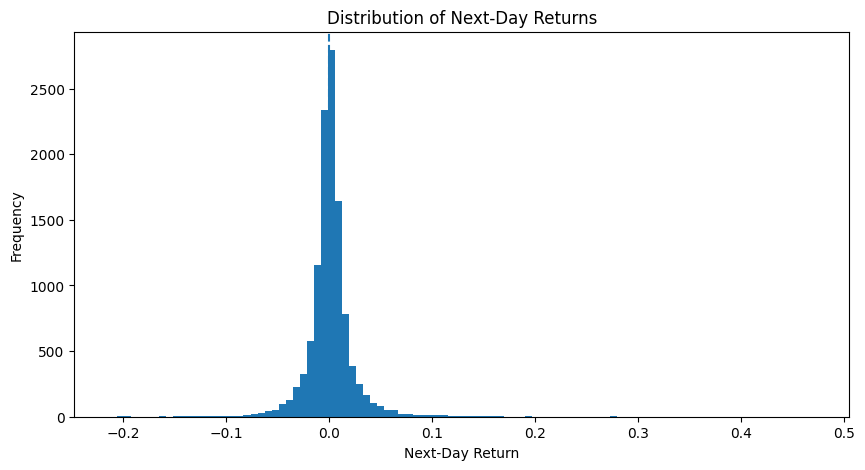

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df[target_return], bins=100)
plt.axvline(0, linestyle="--")
plt.title("Distribution of Next-Day Returns")
plt.xlabel("Next-Day Return")
plt.ylabel("Frequency")
plt.show()

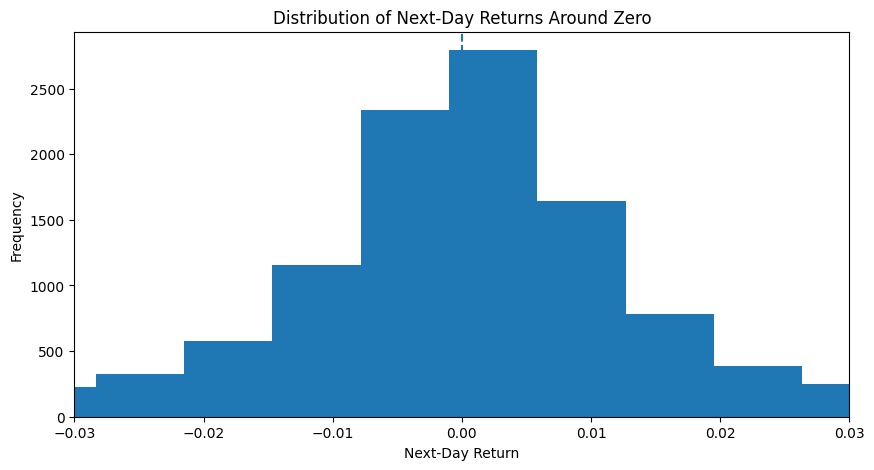

In [151]:
plt.figure(figsize=(10, 5))
plt.hist(df[target_return], bins=100)
plt.xlim(-0.03, 0.03)
plt.axvline(0, linestyle="--")
plt.title("Distribution of Next-Day Returns Around Zero")
plt.xlabel("Next-Day Return")
plt.ylabel("Frequency")
plt.show()

In [156]:
share_tiny = df[target_return].between(-0.005, 0.005).mean()
snr = df[target_return].mean() / df[target_return].std()
autocorr_1 = df[target_return].autocorr(lag=1)

if share_tiny > 0.60:
    print("Many returns are very close to zero. Direction prediction may be difficult.")

if abs(snr) < 0.05:
    print("Mean return is tiny relative to volatility. Regression target is likely noisy.")

if abs(autocorr_1) < 0.05:
    print("Lag-1 autocorrelation is weak. There may be little simple persistence.")

if abs(autocorr_1) > 0.10:
    print("There may be some persistence or mean-reversion worth investigating.")

Mean return is tiny relative to volatility. Regression target is likely noisy.
Lag-1 autocorrelation is weak. There may be little simple persistence.


# Modelling Implication